# Practical: California Housing Prediction using MLP

**Objective:** Build an end-to-end regression pipeline using a Multi-Layer Perceptron (MLP), focusing on Sigmoid activation, min-max scaling, and real-world deployment.

**Data Ingestion**

We use kagglehub to fetch a real-world dataset.



In [12]:
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Download dataset
path = kagglehub.dataset_download("dhirajnirne/california-housing-data")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Simple Preprocessing: handle categories and missing values
df = pd.get_dummies(df, drop_first=True).dropna()
df.head()

Using Colab cache for faster access to the 'california-housing-data' dataset.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


**Discussion:** Why use an API like kagglehub instead of uploading a CSV manually?

(***Hint:*** Think about automation and reproducibility).

**Data Segregation**

Before scaling, we split the data.



In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# 3-Way Split: 60% Train, 20% Val, 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 12259, Val size: 4087, Test size: 4087


**Critical Thinking:**

Why is *Split then Scale* the only scientifically valid method? What is "*Data Leakage*"?

**MinMax Scaling**

We use MinMaxScaler because our MLP uses Sigmoid activation.



In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Fit ONLY on Training data to prevent "peeking" into the future
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

**Question:**

If the data had massive outliers, would min-max still be the best choice?

**MLP Architecture & Training**

We are using a small-scale architecture: 2 Hidden Layers with 3 Nodes each.

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf.fit(X_train, y_train)

Training Random Forest...


RandomForestRegressor(max_depth=20, n_estimators=200, n_jobs=-1,
                      random_state=42)

**Performance Evaluation**

We measure the error and the signal-to-noise ratio.

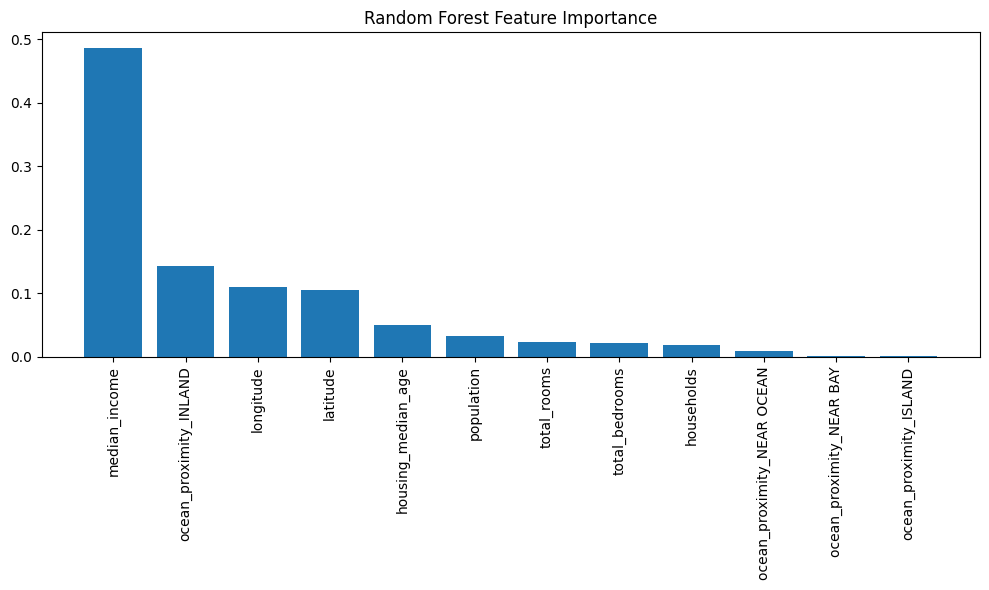

In [19]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

indices = np.argsort(importance)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(indices)), importance[indices])
plt.xticks(range(len(indices)),
           X.columns[indices],
           rotation=90)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

**Instructions:**

Answer the following questions based on your observations of the training process and the Loss Curve.

1. If we increased our hidden layers from `2 to 10`, would the model learn faster or would the "Vanishing Gradient" make it stop learning entirely?

2. If your `R-squared` is low, is it because the model is Underfitting (too simple) or Overfitting (too complex)? How would doubling the nodes from `3 to 6` change the Loss Curve?

3. If the loss curve is "jittery" (vibrating up and down aggressively), does that mean the learning rate is too high or too low?

4. We set `max_iter=1500` but enabled `early_stopping=True`. If the training stops early at iteration `400`, why did the computer decide to quit? How does this protect the model from "memorising" the training data?

**Cloud Deployment**

We use Gradio to create a web-based predictor.

In [20]:
!pip install gradio -q
import gradio as gr

def predict_price(*args):
    raw_input = np.array([args])
    prediction = rf.predict(raw_input)
    return f"Predicted House Value: ${prediction[0]:,.2f}"

# Create UI inputs based on feature count
ui_inputs = [gr.Number(label=name) for name in X.columns]

app = gr.Interface(
    fn=predict_price,
    inputs=ui_inputs,
    outputs="text",
    title="California Housing Price Predictor",
    description="Deploying a Sigmoid MLP model trained on scaled housing data."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://50205f7cf74f03f746.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Checklist:**

1. Can you explain why 3 nodes might limit the model's "intelligence"?
2. Why did we increase `max_iter` for Sigmoid compared to standard ReLU?
3. Does the Gradio link work on your mobile browser?